In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [340]:
# importando parâmetros
struc_par_path = 'parameters/structural.csv'
inter_par_path = 'parameters/interaction.csv'
structural = pd.read_csv(struc_par_path, sep=';', decimal=',')
interaction = pd.read_csv(inter_par_path, sep=';', decimal=',')

R = structural[['Secondary', 'Volume R']].to_numpy()
Q = structural[['Secondary', 'Surface Area Q']].to_numpy()
A = interaction.iloc[:, 1:].to_numpy()

## Implementação UNIFAC

In [341]:
def get_species_parameters(secondary_groups:np.ndarray, rk:np.ndarray=R, qk:np.ndarray=Q) -> tuple[np.ndarray, np.ndarray]:
    # Ordenando vetores com base nos grupos secundários
    rk = rk[np.argsort(rk[:, 0])]
    qk = qk[np.argsort(qk[:, 0])]

    r = rk[np.searchsorted(rk[:, 0], secondary_groups), 1]
    q = qk[np.searchsorted(qk[:, 0], secondary_groups), 1]

    return r, q


def assemble_interaction_matrix(species:dict, temperature:float, amn:np.ndarray=A):
    # Obtendo todos os grupos
    groups = np.array(sorted({
        (group[0], group[1])
        for molecule in species.values()
        for group in molecule
    }))
    # Índices dos grupos na tabela amn
    main_groups = groups[:, 0] - 1
    # Sequencia de grupos secundários que psi_mn se baseia
    # sec_order = groups[:, 1]       
    psi_mn = np.exp(-amn[np.ix_(main_groups, main_groups)] / temperature)
    return psi_mn


def assemble_groups_matrix(species:dict):
    # Montando arrays com grupos secundários
    data = np.array([
        [i, group[1], group[2]]
        for i, molecule in enumerate(species.values())
        for group in molecule
    ])
    # Obtendo grupos secundários únicos
    unique_sec = np.sort(np.unique(data[:, 1]))

    # Matriz de resposta
    arr = np.zeros((len(unique_sec), len(species)), dtype=int) 

    # Índices das linhas em data que contém os grupos secundários
    row_idx = np.searchsorted(unique_sec, data[:, 1])

    # Coluna i = espécie i
    col_idx = data[:, 0]

    arr[row_idx, col_idx] = data[:, 2]
    return unique_sec, arr


def combinatorial_contribution(composition:np.ndarray, group_matrix:np.ndarray, rk:np.ndarray, qk:np.ndarray, z=10):
    ri = rk @ group_matrix
    qi = qk @ group_matrix
    li = z/2 * (ri - qi) - (ri - 1)
    # Calculo de phi_i
    den_phi = composition @ ri
    phi_i = (composition * ri) / den_phi
    # Calculo de theta_i
    den_theta = composition @ qi
    theta_i = (composition * qi) / den_theta
    # Ponderação de li
    l_mix = composition @ li
    # Contribuição combinatorial
    ln_comb = (
        np.log(phi_i/composition)
        + (z/2) * qi * np.log(theta_i/phi_i)
        + li
        - (phi_i/composition) * l_mix
    )
    return ln_comb


def calculate_group_lngamma(composition:np.ndarray, groups_matrix:np.ndarray, qk:np.ndarray, interaction_matrix:np.ndarray):
    composition = np.atleast_2d(composition)
    # Calculando Xk
    arr_sum = groups_matrix.sum(axis=0)
    den = composition @ arr_sum
    xk = (composition @ groups_matrix.T) / den[:, None]
    
    # Calculando Theta_m
    den_theta = xk @ qk
    theta_m = (xk * qk) / den_theta[:, None]

    # Calculando ln Gamma i
    den = theta_m @ interaction_matrix
    term1 = np.log(den)
    term2 = (
        (interaction_matrix[None, :, :] * theta_m[:, None, :]) / den[:, None, :]
    ).sum(axis=2)
    ln_gamma = qk * (1 - term1 - term2)
    return ln_gamma


def residual_contribution(composition:np.ndarray, groups_matrix:np.ndarray, qk:np.ndarray, interaction_matrix:np.ndarray):
    ln_gamma = calculate_group_lngamma(composition, groups_matrix, qk, interaction_matrix)
    ln_gamma_std = calculate_group_lngamma(np.identity(len(composition)), groups_matrix, qk, interaction_matrix)
    delta = ln_gamma - ln_gamma_std
    ln_res = np.sum(
        groups_matrix.T * delta,
        axis=1
    )
    return ln_res


def unifac(species:dict, composition:np.ndarray, temperature:float):
    unique, group_matrix = assemble_groups_matrix(species)
    r, q = get_species_parameters(unique)
    ln_gamma_comb = combinatorial_contribution(composition, group_matrix, r, q)
    psi = assemble_interaction_matrix(species, temperature)
    ln_gamma_res = residual_contribution(composition, group_matrix, q, psi)
    return ln_gamma_res + ln_gamma_comb

In [342]:
# Definindo parâmetros
temperatura = 307  # K
composicao = np.array([0.047, 0.953])

# Definindo moléculas e seus grupos
# Espécie1: [
#      [Main Group, Secondary Group, Qty]1,
#      [Main Group, Secondary Group, Qty]2,
#   ]
especies = {
    "1": [
        [1, 1 , 1],
        [9, 18, 1],
    ],
    "2": [
        [1, 1, 2],
        [1, 2, 3],
    ]
}


In [343]:
# Testes
ln_gammas = unifac(especies, composicao, temperatura)
print(np.exp(ln_gammas))

[4.99203431 1.00526021]


In [344]:
x1 = np.linspace(1E-5, 0.99999, 101)
x2 = 1 - x1
composicao = np.stack([x1, x2], axis=1)
gammas = np.zeros(composicao.shape)
for i, row in enumerate(composicao):
    gammas[i, :] = np.exp(unifac(especies, row, temperatura))

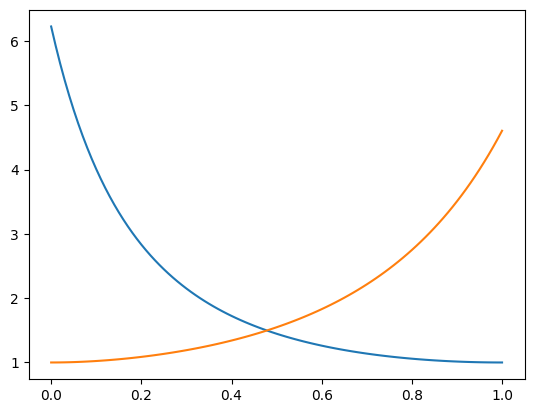

In [ ]:
plt.plot(x1, gammas)
plt.show()